# Fitness Tracker Insights Dashboard
Sample data: 120 users, 28 days (steps, sleep, calories)

## Top insight
Average daily steps fell only 1.7% from week 1 to week 4, so the overall trend looks stable. But 8 users (6.7%) dropped to about 30% of their normal steps for 5 days in a row. The average can hide users who are slipping, so the team should follow up with them early.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [36]:
np.random.seed(42)

num_users = 120
num_days = 28
start_date = pd.Timestamp("2026-08-01")

user_ids = [f"user_{i:03d}" for i in range(1, num_users + 1)]
dates = pd.date_range(start_date, periods=num_days, freq="D")

rows = []
for user in user_ids:
    base_steps = np.random.randint(4000, 12000)
    base_sleep = np.random.uniform(5.5, 8.5)
    base_calories = np.random.randint(1800, 2800)

    for date in dates:
        steps = max(0, int(np.random.normal(base_steps, 1500)))
        sleep = round(max(3, np.random.normal(base_sleep, 0.8)), 1)
        calories = max(1200, int(np.random.normal(base_calories, 200)))
        rows.append([user, date, steps, sleep, calories])

df = pd.DataFrame(rows, columns=["user_id", "date", "steps", "sleep_hours", "calories"])
df.head()


,user_id,date,steps,sleep_hours,calories
0,user_001,2026-08-01,12241,9.1,2023
1,user_001,2026-08-02,10918,9.2,2223
2,user_001,2026-08-03,10565,8.3,1977
3,user_001,2026-08-04,10571,8.1,1687
4,user_001,2026-08-05,8682,7.4,1867


In [37]:
print(df.shape)
print(df.dtypes)
print(df.describe())


(3360, 5)
user_id                object
date           datetime64[ns]
steps                   int64
sleep_hours           float64
calories                int64
dtype: object
                      date         steps  sleep_hours     calories
count                 3360   3360.000000  3360.000000  3360.000000
mean   2026-08-14 12:00:00   8145.890179     6.927024  2268.650893
min    2026-08-01 00:00:00      0.000000     3.200000  1238.000000
25%    2026-08-07 18:00:00   6193.750000     6.100000  2011.000000
50%    2026-08-14 12:00:00   8231.500000     6.900000  2259.000000
75%    2026-08-21 06:00:00  10057.750000     7.700000  2524.000000
max    2026-08-28 00:00:00  16538.000000    10.700000  3429.000000
std                    NaN   2650.871429     1.160977   351.445168


In [38]:
drop_users = np.random.choice(user_ids, size=8, replace=False)
cutoff = pd.Timestamp("2026-08-24")  # last 5 days: Aug 24-28

mask = df["user_id"].isin(drop_users) & (df["date"] >= cutoff)
df.loc[mask, "steps"] = (df.loc[mask, "steps"] * 0.3).astype(int)

print(sorted(drop_users))

[np.str_('user_005'), np.str_('user_011'), np.str_('user_012'), np.str_('user_017'), np.str_('user_059'), np.str_('user_078'), np.str_('user_082'), np.str_('user_087')]


In [39]:
df["week"] = ((df["date"] - df["date"].min()).dt.days // 7) + 1

weekly = df.groupby("week")[["steps", "sleep_hours", "calories"]].mean().round(1)
print(weekly)


       steps  sleep_hours  calories
week                               
1     8117.1          6.9    2264.9
2     8126.0          6.9    2275.2
3     8102.8          6.9    2267.3
4     7982.0          7.0    2267.2


## Weekly trends

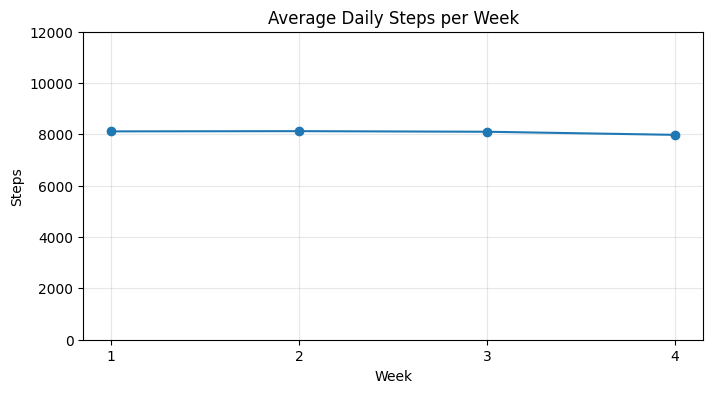

In [40]:
plt.figure(figsize=(8, 4))
plt.plot(weekly.index, weekly["steps"], marker="o", color="tab:blue")
plt.title("Average Daily Steps per Week")
plt.xlabel("Week")
plt.ylabel("Steps")
plt.xticks(weekly.index)
plt.grid(alpha=0.3)
plt.ylim(0, 12000)
plt.show()


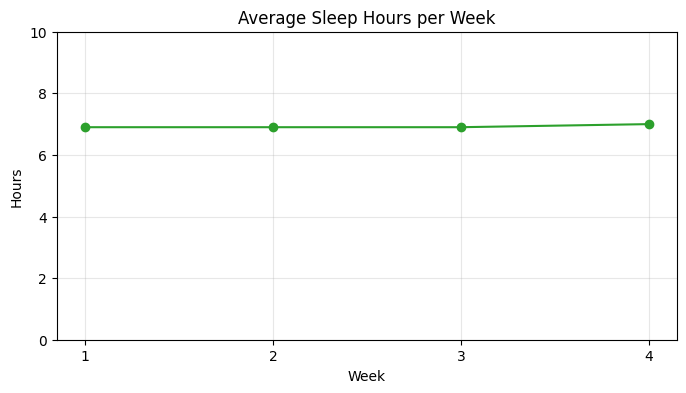

In [41]:
plt.figure(figsize=(8, 4))
plt.plot(weekly.index, weekly["sleep_hours"], marker="o", color="tab:green")
plt.title("Average Sleep Hours per Week")
plt.xlabel("Week")
plt.ylabel("Hours")
plt.xticks(weekly.index)
plt.grid(alpha=0.3)
plt.ylim(0,10)
plt.show()

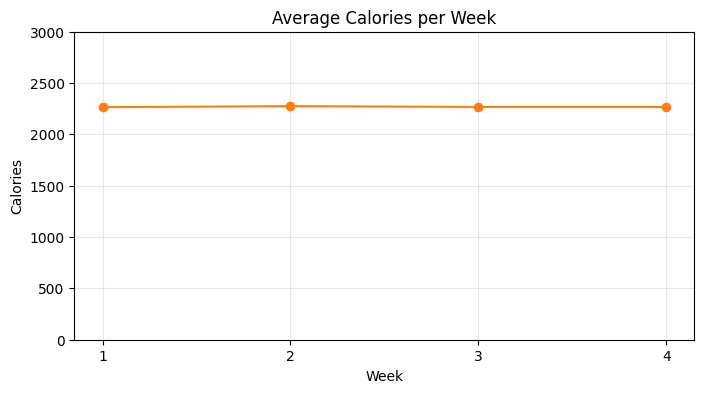

In [42]:
plt.figure(figsize=(8, 4))
plt.plot(weekly.index, weekly["calories"], marker="o", color="tab:orange")
plt.title("Average Calories per Week")
plt.xlabel("Week")
plt.ylabel("Calories")
plt.xticks(weekly.index)
plt.grid(alpha=0.3)
plt.ylim(0, 3000)
plt.show()

## Most Active Users (Top 10)

In [43]:
leaderboard = (
    df.groupby("user_id")["steps"]
    .mean()
    .round(0)
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
leaderboard.columns = ["user_id", "avg_daily_steps"]
leaderboard.index = leaderboard.index + 1
print(leaderboard)
print(sorted(drop_users))

     user_id  avg_daily_steps
1   user_016          11881.0
2   user_009          11852.0
3   user_097          11814.0
4   user_111          11730.0
5   user_031          11710.0
6   user_006          11664.0
7   user_019          11479.0
8   user_058          11334.0
9   user_048          11110.0
10  user_089          11035.0
[np.str_('user_005'), np.str_('user_011'), np.str_('user_012'), np.str_('user_017'), np.str_('user_059'), np.str_('user_078'), np.str_('user_082'), np.str_('user_087')]


In [44]:
df = df.sort_values(["user_id", "date"]).reset_index(drop=True)

user_median = df.groupby("user_id")["steps"].transform("median")
df["dropped"] = df["steps"] < 0.5 * user_median

print(df[df["user_id"] == drop_users[0]].tail(8)[["date", "steps", "dropped"]])

           date  steps  dropped
1644 2026-08-21   8549    False
1645 2026-08-22   7789    False
1646 2026-08-23   7454    False
1647 2026-08-24   1666     True
1648 2026-08-25   1885     True
1649 2026-08-26   1852     True
1650 2026-08-27    963     True
1651 2026-08-28   2017     True


## Users flagged for dropped activity

In [45]:
def longest_streak(series):
    longest = 0
    current = 0
    for value in series:
        if value:
            current += 1
            longest = max(longest, current)
        else:
            current = 0
    return longest

streaks = df.groupby("user_id")["dropped"].apply(longest_streak)
flagged = streaks[streaks >= 3].sort_values(ascending=False)

print(flagged)
print(sorted(drop_users))

user_id
user_005    5
user_011    5
user_012    5
user_017    5
user_059    5
user_078    5
user_082    5
user_087    5
Name: dropped, dtype: int64
[np.str_('user_005'), np.str_('user_011'), np.str_('user_012'), np.str_('user_017'), np.str_('user_059'), np.str_('user_078'), np.str_('user_082'), np.str_('user_087')]


In [46]:
print(set(flagged.index) == set(drop_users))

True


In [47]:
w1 = weekly.loc[1, "steps"]
w4 = weekly.loc[4, "steps"]
change = (w4 - w1) / w1 * 100

overlap = set(flagged.index) & set(leaderboard["user_id"])

print(f"Week 1 avg steps: {w1}")
print(f"Week 4 avg steps: {w4}")
print(f"Change: {change:.1f}%")
print(f"Flagged users: {len(flagged)}")
print(f"Flagged users who are also in the top 10: {sorted(overlap)}")

Week 1 avg steps: 8117.1
Week 4 avg steps: 7982.0
Change: -1.7%
Flagged users: 8
Flagged users who are also in the top 10: []


In [48]:
import json
from google.colab import files

export = {
    "weekly": weekly.reset_index().to_dict(orient="records"),
    "leaderboard": leaderboard.to_dict(orient="records"),
    "flagged": [{"user_id": u, "streak_days": int(s)} for u, s in flagged.items()],
    "summary": {
        "users": 120,
        "days": 28,
        "week1_steps": float(w1),
        "week4_steps": float(w4),
        "change_pct": round(float(change), 1),
    },
}

with open("data.json", "w") as f:
    json.dump(export, f, indent=2)

files.download("data.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>